# Libraries

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
import geopandas as gpd
from PIL import Image
#----------------------------------------
import warnings
warnings.filterwarnings('ignore')

# 1) Functions

In [19]:
def load_datasets(path1, path2, path3):

    #Effluente outflow from three Sewage Treatment Plants (STPs) in Recife city
    df = pd.read_csv(path1)
    df['date'] = pd.to_datetime(df['date'], format = '%d/%m/%Y')

    for line in range(len(df)):

        #Cumulative Sewage Outflow (CSO)
        df.loc[line, 'cso'] = round((df.loc[line, 'mean_outflow'] * 60 * 60 * 24 * df.loc[line, 'days']),2)

    df['season'] = df['season'].apply(lambda x: 'Dry' if x == 'dry' else 'Wet')
    #-------------------------------------------------------------------------------------------------------------------
    ww_production = pd.read_csv(path2)
    ww_production['WWuc_million_m3_yr'] = ww_production['WWp_million_m3_yr'] - ww_production['WWc_million_m3_yr']
    ww_10producers = ww_production.sort_values('WWp_million_m3_yr', ascending = False).head(10)
    ww_production['Economic_Classification'] = pd.Categorical(ww_production['Economic_Classification'], 
                                                              categories = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'])
    ww_production = ww_production.sort_values('Economic_Classification').reset_index(drop=True)
    #-------------------------------------------------------------------------------------------------------------------
    ww_stations = pd.read_csv(path3, encoding='latin-1')

    return df, ww_production, ww_10producers, ww_stations
#------------------------------------------------------------------------------------------------------------------------
def bar_graph_countries(dataframe):
    
    fig1, ax1 = plt.subplots(figsize = (10,5))

    collected = dataframe['WWc_million_m3_yr']
    uncollected = dataframe['WWuc_million_m3_yr']
    
    ax1.bar(dataframe['Country'], collected, color = 'blue')
    ax1.bar(dataframe['Country'], uncollected, color = 'red', bottom = collected)
    ax1.set_ylabel('WWp (million m3/year)', fontsize = 11)
    ax1.set_xlabel('Country', fontsize = 11)
    ax1.legend(['Collected', 'Uncollected'], frameon = False, title = 'Quality of wastewater')
    ax1.tick_params(axis = 'x', labelrotation = 90)
#-----------------------------------------------------------------------------------------------------------------------
def boxplot_economic_classification(dataframe):

    fig2, ax2 = plt.subplots(figsize = (10,5))

    sns.boxplot(dataframe, 
                x = dataframe['Economic_Classification'], 
                y = dataframe['WWp_million_m3_yr'], fill = True, color = 'white', linecolor = 'black', log_scale = True, ax = ax2)
    sns.swarmplot(dataframe, 
                  x = dataframe['Economic_Classification'], 
                  y = dataframe['WWp_million_m3_yr'], size = 4, edgecolor = 'red', hue = 'Region', ax = ax2)
    
    ax2.set_ylabel('WWp (million m3/year)', fontsize=11)
    ax2.set_xlabel('Country economic classification', fontsize=11)
    ax2.tick_params(axis = 'both', pad = 7)
    ax2.set_xticklabels(labels = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'], rotation = 90)
    ax2.yaxis.labelpad = 15
    ax2.legend(frameon = False)
    sns.move_legend(ax2, 'upper left', bbox_to_anchor=(1, 1.02));
#-----------------------------------------------------------------------------------------------------------------------
def wastewater_plants_count(dataframe1, dataframe2):

    df1 = dataframe1.loc[dataframe1['COAST_10KM'] == 1, ['COUNTRY', 'WASTE_ID']]

    contagem_ww_plants = []

    countries = list(dataframe2['Country'])
    countries[7] = 'Russia'
    
    for country in countries:

        df2 = df1.loc[df1['COUNTRY'] == country, ['COUNTRY', 'WASTE_ID']]
        lista = [df2['COUNTRY'].unique()[0], df2['WASTE_ID'].count()]
        contagem_ww_plants.append(lista)

    contagem_ww_plants = pd.DataFrame(contagem_ww_plants, columns =['Country', 'Quantity'])
    coastline = [19924, 14500, 7000, 7491, 54716, 29751, 2450, 37653, 9330, 2389] #Reference: https://www.cia.gov/the-world-factbook/field/coastline/
    population = [341963408, 1416043270, 1409128296 ,  220051512, 281562465, 123201945, 111247248, 140820810, 130739927, 84119100]  
                                                                                  #https://www.cia.gov/the-world-factbook/field/population-distribution/
    contagem_ww_plants['Coastline (km)'] = coastline
    contagem_ww_plants['Population'] = population

    return contagem_ww_plants
#-----------------------------------------------------------------------------------------------------------------------
def temporal_series(df):

    #Cabanga, Peixinhos and Mangueira STPs
    cabanga = df.loc[df['stp'] == 'Cabanga', :]
    peixinhos = df.loc[df['stp'] == 'Peixinhos', :]
    mangueira = df.loc[df['stp'] == 'Mangueira', :]

    fig1, ax = plt.subplots(1, 2, figsize = (10,5), gridspec_kw ={'width_ratios': [7, 6]})
    fig1.tight_layout(pad = 4)
    ax[0].plot(cabanga['date'], cabanga['mean_outflow'], color = 'red')
    ax[0].plot(peixinhos['date'], peixinhos['mean_outflow'], color = 'blue')
    ax[0].set_xlabel('Month-Year', fontsize = 12, labelpad = 10)
    ax[0].set_ylabel('Effluent Outflow (m3/s)', fontsize = 12, labelpad = 10)
    ax[0].set_yticks([0, 0.25, 0.50, 0.75, 1])
    ax[0].tick_params(axis= 'x', labelrotation = 90)
    ax[0].tick_params(axis= 'y')
    ax[0].legend(['Cabanga', 'Peixinhos'], frameon = False)

    ax[1].plot(mangueira['date'], mangueira['mean_outflow'], color = 'orange')
    ax[1].set_xlabel('Month-Year', fontsize = 12, labelpad = 10)
    ax[1].set_ylabel('Effluent Outflow (m3/s)', fontsize = 12, labelpad = 10)
    ax[1].set_yticks([0, 0.02, 0.04, 0.06, 0.08])
    ax[1].legend(['Mangueira'], frameon = False)

    ax[1].tick_params(axis= 'x', labelrotation = 90)
#-------------------------------------------------------------------------------------------------------------------
def dataframe(df):

    categories = ['Cabanga', 'Peixinhos', 'Mangueira']
    df['stp'] = pd.Categorical(df['stp'], categories = categories, ordered = True)
    df = df.sort_values('stp')
    df = df[['stp', 'mean_outflow', 'cso']].groupby(['stp'], observed = True).agg(['min', 'max', 'median']).round(decimals=2).reset_index()

    return df
#-------------------------------------------------------------------------------------------------------------------
def recife_map(recife, macrodrenagem, rio_capibaribe, baixo_estuario, rio_beberibe, rio_tejipio, bacia_portuaria_pina, microdrenagem):

    recife = gpd.read_file(recife)
    macrodrenagem = gpd.read_file(macrodrenagem)
    rio_capibaribe = gpd.read_file(rio_capibaribe)  
    baixo_estuario = gpd.read_file(baixo_estuario) 
    rio_beberibe = gpd.read_file(rio_beberibe) 
    rio_tejipio = gpd.read_file(rio_tejipio) 
    bacia_portuaria_pina = gpd.read_file(bacia_portuaria_pina) 
    microdrenagem = gpd.read_file(microdrenagem)

    fig, ax = plt.subplots(1, 2, figsize = (12,8))

    recife.plot(ax = ax[0], 
                figsize = (8,6),
                color = 'gray',
                alpha = 0.6, 
                edgecolor = 'black',
                linewidth = 0.7,
                autolim = True)\
               .set_axis_off()
    
    macrodrenagem.plot(ax = ax[0],
                      color = 'black',
                       linewidth = 0.5)\
               .set_axis_off()
    
    rio_capibaribe.plot(ax = ax[0],
                              color = 'white',
                       linewidth = 1.2)
    
    baixo_estuario.plot(ax = ax[0],
                       color = 'white',
                       linewidth = 1.2)
    
    rio_beberibe.plot(ax = ax[0],
                       color = 'white')
    
    rio_tejipio.plot(ax = ax[0],
                       color = 'white')
    
    bacia_portuaria_pina.plot(ax = ax[0],
                       color = 'white')
    
    ax[0].annotate('A', xy = (-34.865, -7.93))
    #-------------------------------------------------------------------
    recife.plot(ax = ax[1], 
                figsize = (8,6),
                color = 'gray',
                alpha = 0.6, 
                edgecolor = 'black',
                linewidth = 0.7,
                autolim = True)\
               .set_axis_off()
    
    microdrenagem.plot(ax = ax[1],
                      color = 'black',
                       linewidth = 0.1)\
               .set_axis_off()
    
    rio_capibaribe.plot(ax = ax[1],
                              color = 'white',
                       linewidth = 1.2)
    
    baixo_estuario.plot(ax = ax[1],
                       color = 'white',
                       linewidth = 1.2)
    
    rio_beberibe.plot(ax = ax[1],
                       color = 'white')
    
    rio_tejipio.plot(ax = ax[1],
                       color = 'white')
    
    bacia_portuaria_pina.plot(ax = ax[1],
                       color = 'white')
    
    ax[1].annotate('B', xy = (-34.865, -7.93))
#--------------------------------------------------------------------------------------------------------------------
def recife_landuse_landcover(recife, rio_capibaribe, rio_beberibe, rio_tejipio,  
                             baixo_estuario, medio_estuario_capiba, medio_estuario_tejipio, medio_estuario_beberibe, alto_estuario_capiba,
                             bacia_portuaria_pina, cobertura_solo_recife):

    recife = gpd.read_file(recife)
    rio_capibaribe = gpd.read_file(rio_capibaribe)
    rio_beberibe = gpd.read_file(rio_beberibe) 
    rio_tejipio = gpd.read_file(rio_tejipio) 
    baixo_estuario = gpd.read_file(baixo_estuario) 
    medio_estuario_capiba = gpd.read_file(medio_estuario_capiba)
    medio_estuario_tejipio = gpd.read_file(medio_estuario_tejipio)
    medio_estuario_beberibe = gpd.read_file(medio_estuario_beberibe)
    alto_estuario_capiba = gpd.read_file(alto_estuario_capiba)
    bacia_portuaria_pina = gpd.read_file(bacia_portuaria_pina) 
    cobertura_solo_recife = gpd.read_file(cobertura_solo_recife)

    cobertura_solo_recife['classe04'] = cobertura_solo_recife['classe03']\
                                                                    .apply(lambda x: 'Mangrove'           if   x == 'mangue' 
                                                                           else      'Terrestrial Plants' if ((x == 'ffinicial')|
                                                                                                              (x == 'herbacea')|
                                                                                                              (x == 'ffdensa')|
                                                                                                              (x == 'cultagri')|
                                                                                                              (x == 'ffaberta')) 
                                                                           else      'Lagoon'             if   x == 'lagoa'
                                                                           else      'Road network'       if   x == 'mviaria' 
                                                                           else      'Urban area'         if   x == 'edurb'
                                                                           else      'Beach'              if   x == 'praia'
                                                                           else      'Sea'                if   x == 'mar'
                                                                           else      'River'              if   x == 'cursodag'
                                                                           else      'Others')

    cobertura_solo_recife = cobertura_solo_recife.loc[(cobertura_solo_recife['classe04'] != 'River')&(cobertura_solo_recife['classe04'] != 'Sea'), :]
    color_dict = {'Mangrove':'tab:green',
                  'Terrestrial Plants':'tab:blue', 
                  'Lagoon':'tab:red', 
                  'Road network':'tab:black', 
                  'Urban area':'tab:gray',
                  'Beach':'tab:olive', 
                  'Others':'tab:orange'}

    cobertura_solo_recife['Color'] = cobertura_solo_recife['classe04'].map(color_dict)
    
    fig2, ax2 = plt.subplots(1, 2, figsize = (12,8))

    recife.plot(ax = ax2[0], 
                figsize = (8,6),
                color = 'gray',
                alpha = 0.6, 
                edgecolor = 'black',
                linewidth = 0.7,
                autolim = True)\
               .set_axis_off()
    
    rio_capibaribe.plot(ax = ax2[0],
                              color = 'white',
                       linewidth = 1.2)
    
    baixo_estuario.plot(ax = ax2[0],
                       color = 'white',
                       linewidth = 1.2)
    
    rio_beberibe.plot(ax = ax2[0],
                       color = 'white')
    
    rio_tejipio.plot(ax = ax2[0],
                       color = 'white')
    
    bacia_portuaria_pina.plot(ax = ax2[0],
                       color = 'white')
    #-------------------------------------------------------------------    
    colors = ['olive', 'red', 'green', 'orange', 'black',  'blue', 'grey']
    pal = sns.xkcd_palette(colors)
    cmap = ListedColormap(pal.as_hex())
    
    cobertura_solo_recife.plot(ax = ax2[0],
                               column = 'classe04', categorical = True, 
                               legend = True,
                               cmap=cmap,
                               legend_kwds ={"loc": "center left",
                                             "bbox_to_anchor": (1, 0.25),
                                             "fontsize": 10,
                                             "frameon": False})
    
    ax2[0].annotate('C', xy = (-34.865, -7.93))
    #-------------------------------------------------------------------    
    recife.plot(ax = ax2[1], 
                figsize = (8,6),
                color = 'gray',
                alpha = 0.6, 
                edgecolor = 'black',
                linewidth = 0.7,
                autolim = True)\
               .set_axis_off()
    
    rio_capibaribe.plot(ax = ax2[1],
                        color = 'white',
                        linewidth = 1.2)
    
    rio_beberibe.plot(ax = ax2[1],
                       color = 'white')
    
    rio_tejipio.plot(ax = ax2[1],
                       color = 'white')
    
    baixo_estuario.plot(ax = ax2[1],
                        color = 'yellow',
                        linewidth = 1.2)
    
    medio_estuario_capiba.plot(ax = ax2[1],
                               color = 'green',
                               linewidth = 1.2)
    
    medio_estuario_tejipio.plot(ax = ax2[1],
                               color = 'green',
                               linewidth = 1.2)
    
    medio_estuario_beberibe.plot(ax = ax2[1], 
                                color = 'green',
                                linewidth = 1.2)
    
    alto_estuario_capiba.plot(ax = ax2[1],
                              color = 'blue',
                              linewidth = 1.2)
    
    ax2[1].annotate('D', xy = (-34.865, -7.93))

# 2) Loading datasets

In [20]:
path1 = 'datasets/stps_recife.csv'
path2 = 'datasets/global_wastewater_production.csv'
path3 = 'datasets/hydrowaste_database.csv'
df1, df2, df3, df4 = load_datasets(path1, path2, path3)
df5 = wastewater_plants_count(df4, df3)
#--------------------------------------------------------
#Shapefiles
recife = 'shapefile/recife.zip'
macrodrenagem = 'shapefile/rede_macrodrenagem_recife.zip'
rio_capibaribe = 'shapefile/rio_capibaribe.zip'
baixo_estuario = 'shapefile/baixo_estuario.zip' 
rio_beberibe = 'shapefile/rio_beberibe.zip'
rio_tejipio = 'shapefile/rio_tejipio.zip'
bacia_portuaria_pina = 'shapefile/bacia_portuaria_pina.zip'
microdrenagem = 'shapefile/rede_microdrenagem_recife.zip'
medio_estuario_capiba = 'shapefile/medio_estuario_capiba.zip'
medio_estuario_beberibe = 'shapefile/medio_estuario_beberibe.zip'
medio_estuario_tejipio = 'shapefile/medio_estuario_tejipio.zip'
alto_estuario_capiba = 'shapefile/alto_estuario_capiba.zip'
cobertura_solo_recife = 'geojson/recife_cobertura_solo.geojson'

# 3) Figures and Dataframes

<h4 style='text-align: justify; color: black;'><u>Figure 1</u> - Wastewater production (WWp) of 10 countries based on the 
dataset published by Jones et al. (2020). WWp is the sum of collected and uncollected wastewater and it is equivalent to return flows from domestic and manufacturing sources (Jones et al., 2021). Uncollected WWp is the total WWp minus collected WWp.</h4>

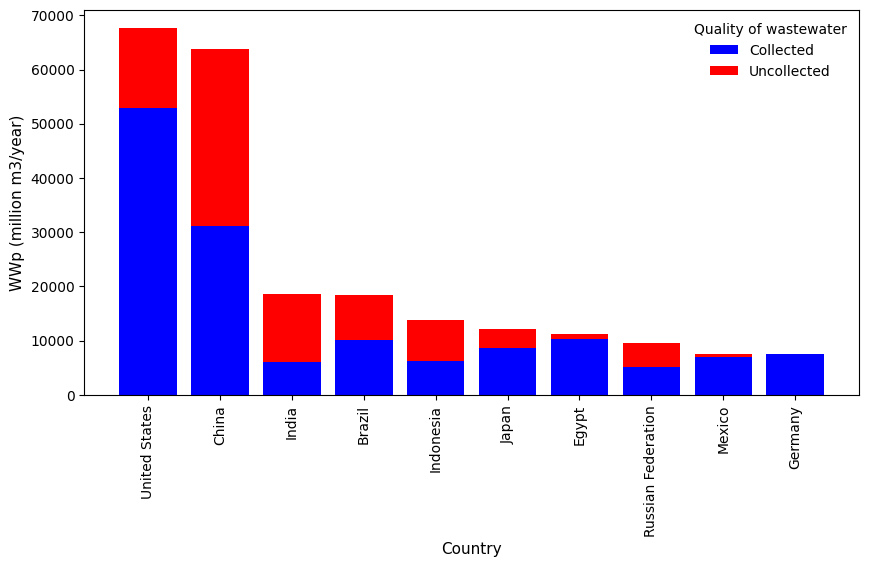

In [64]:
bar_graph_countries(df3)

<h4 style='text-align: justify; color: black;'><u>Figure 2</u> - Boxplot of wastewater production (WWp) of countries grouped by 
economic classification (Jones et al., 2020). The swarmplot exhibits the values of WWp by country from distinct regions.</h4>

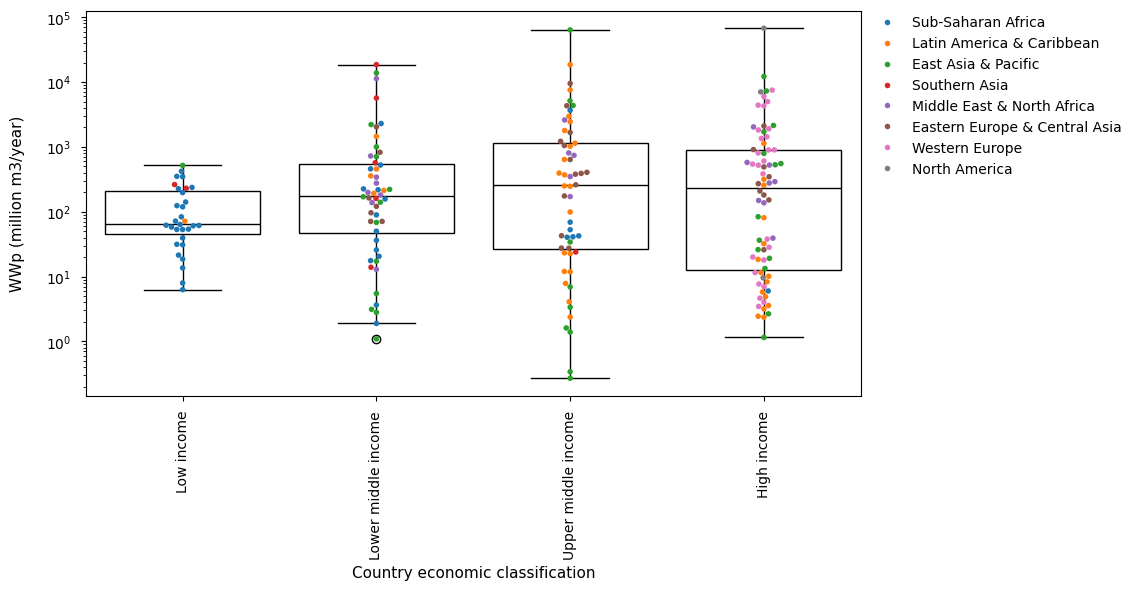

In [76]:
boxplot_economic_classification(df2)

<h4 style='text-align: justify; color: black;'><u>Table 1</u> - Quantity of wastewater treatment plants, extension of coastline and
        total population of the top 10 countries with high wastewater production.</h4>

In [80]:
df5

,Country,Quantity,Coastline (km),Population
0,United States,1287,19924,341963408
1,China,307,14500,1416043270
2,India,86,7000,1409128296
3,Brazil,685,7491,220051512
4,Indonesia,22,54716,281562465
5,Japan,235,29751,123201945
6,Egypt,17,2450,111247248
7,Russia,186,37653,140820810
8,Mexico,383,9330,130739927
9,Germany,184,2389,84119100


<h4 style='text-align: justify; color: black;'><u>Figure 3</u> - Maps of Recife city showing the urban channels (A) and the
underground pipelines network (B) for urban drainage, and the land use/land cover of the city (C) (EMPREL, 2021). The lower (30 < salinity <span>≤</span> 35, yellow), middle (2.5 < salinity <span>≤</span> 30, green) and upper estuaries (salinity <span>≤</span> 2.5, blue) of the Capibaribe Estuarine System according to identified by Noriega et al. (2013) are showed in D.</h4>

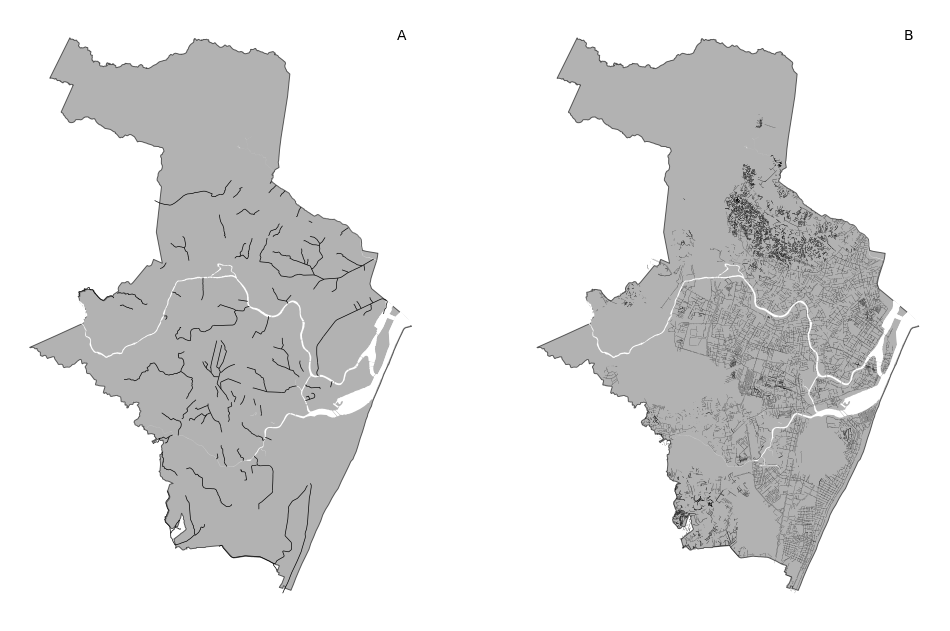

In [4]:
recife_map(recife, macrodrenagem, rio_capibaribe, baixo_estuario, rio_beberibe, rio_tejipio, bacia_portuaria_pina, microdrenagem)

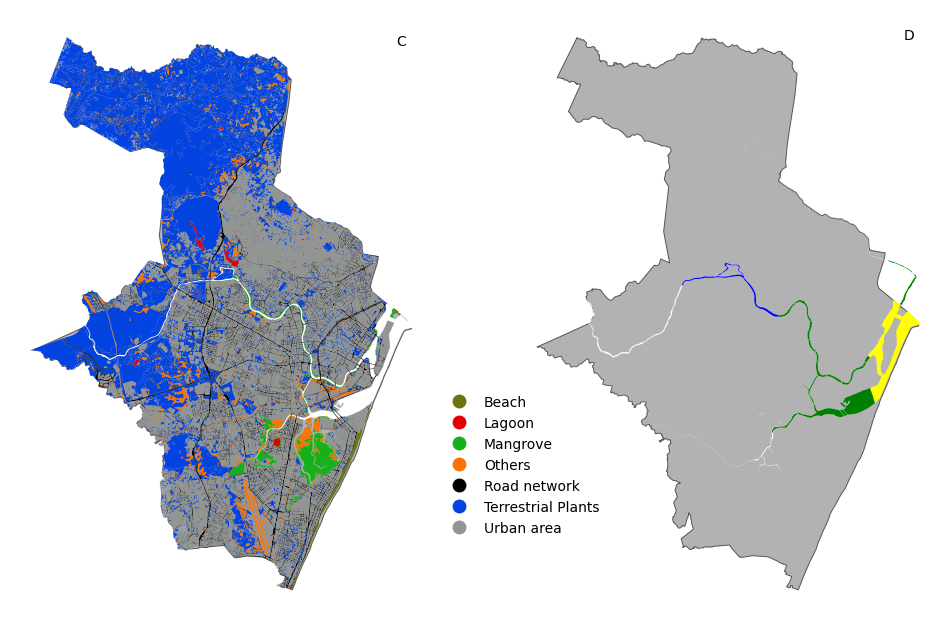

In [21]:
recife_landuse_landcover(recife, rio_capibaribe, rio_beberibe, rio_tejipio,  
                         baixo_estuario, medio_estuario_capiba, medio_estuario_tejipio, medio_estuario_beberibe, alto_estuario_capiba,
                         bacia_portuaria_pina, cobertura_solo_recife)

<h4 style='text-align: justify; color: black;'><u>Table 2</u> - Dataframe of seasonal variation of effluent outflow from Cabanga, Peixinhos and Mangueira STPs</h4>

In [54]:
dataframe(df1)

stp mean_outflow                     cso                       
                      min   max median        min         max     median
0    Cabanga         0.23  0.79   0.32  611907.26  2042107.20  846749.38
1  Peixinhos         0.11  0.54   0.28  292106.30  1449389.38  755094.52
2  Mangueira         0.03  0.06   0.04   70950.82   160056.00  106391.23

<h4 style='text-align: justify; color: black;'><u>Figure 4</u> - Temporal series of effluent outflow from Cabanga, Peixinhos and Mangueira STPs.</h4>

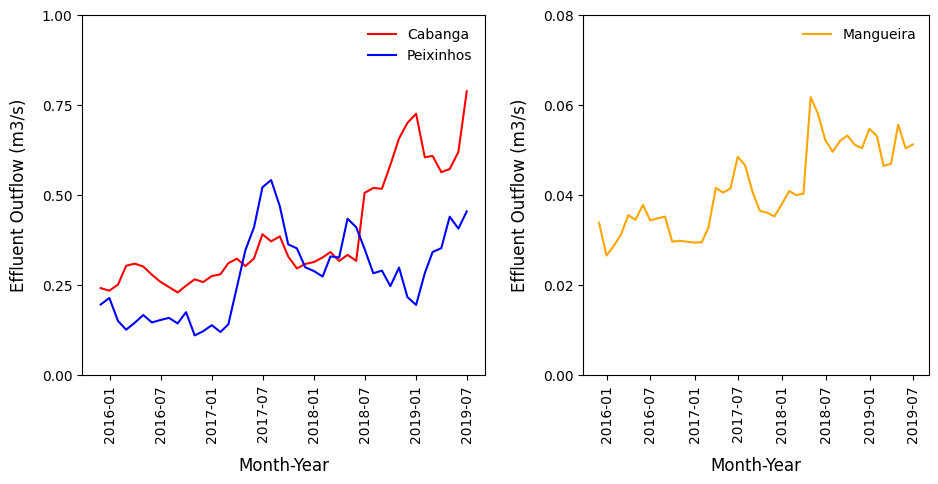

In [53]:
temporal_series(df1)